In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [42]:
data = pd.read_csv("auto-mpg.csv")
df = data.copy()

In [43]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [44]:
df = df.drop(columns='car name')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB


In [86]:
df['horsepower'] = df['horsepower'].replace("?", np.nan)
df['horsepower'] = df['horsepower'].astype(float)
mean_value = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(mean_value)

df['horsepower'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 398 entries, 0 to 397
Series name: horsepower
Non-Null Count  Dtype  
--------------  -----  
398 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


In [87]:
df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.754276,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.821656,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.871927,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.754276,0.821656,0.871927,1.000000,0.837987,-0.673940,-0.411587,-0.418636
weight,-0.831741,0.896017,0.932824,0.837987,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.673940,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.411587,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.418636,-0.581024,0.205873,0.180662,1.000000


<Axes: >

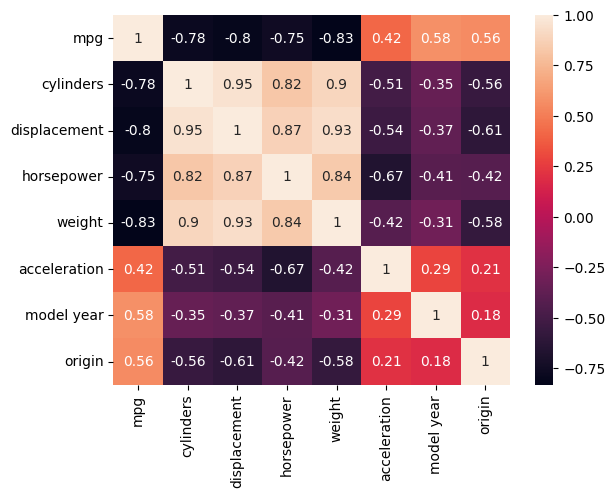

In [90]:
sns.heatmap(df.corr(), annot=True)

In [101]:
X = df.drop("mpg",axis=1)
y = df["mpg"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
model = LinearRegression()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [108]:
y_pred = model.predict(X_test_scaled)

In [117]:
mse = mean_squared_error(y_test, y_pred)
print("mse:", mse)
r2score = r2_score(y_test, y_pred)
print("r2score:", r2score)
rmse = root_mean_squared_error(y_test, y_pred)
print("rmse:", rmse)
mae = mean_absolute_error(y_test, y_pred)
print("mae:", mae)

mse: 8.225824522386748
r2score: 0.8470082090488503
rmse: 2.8680698252285888
mae: 2.2649172886071454


In [131]:
model_2 = LassoCV(cv=10)
model_2.fit(X_train_scaled, y_train)
y_pred_lasso = model_2.predict(X_test_scaled)
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))


model_3 = RidgeCV(cv=10)
model_3.fit(X_train_scaled, y_train)
y_pred_ridge = model_3.predict(X_test_scaled)
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))

Lasso MSE: 8.435978248693363
Ridge MSE: 8.237235375870847


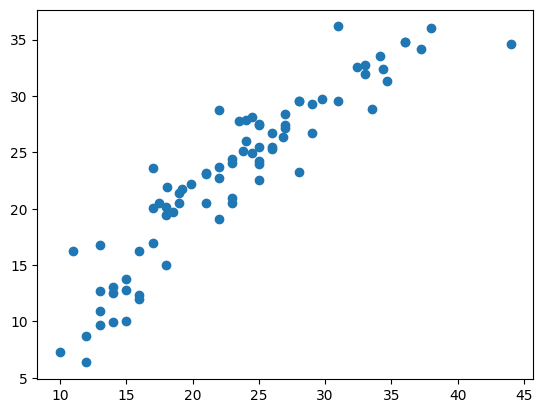

In [137]:
plt.scatter(y_test, y_pred)